
# PHASE 4 FINAL PROJECT



# A MOVIE RECOMMENDER SYSTEM USING THE MOVIELENS LATEST SMALL DATASET



# PHASE 1 - BUSINESS UNDERSTANDING
## Problem statement

Movie streaming platforms face an information overload problem where users are overwhelmed by the sheer volume of movie choices available on streaming platforms. Traditional recommendation approaches suffer from critical limitations i.e Collaborative Filtering struggles with the cold start problem for new users and movies, while Content-Based Filtering suffers from over-specialization, limiting content discovery. Furthermore, the MovieLens dataset reveals that the user-item rating matrix is over 98% sparse, making accurate preference prediction highly challenging.

## Project Objective

The goal of this project is to develop a hybrid recommendations system that combines both filtering techniques to deliver more accurate and personalized movie suggestions, outperforming single-method approaches while handling cold start and data sparsity challenges.




# 2. DATA UNDERSTANDING

The project utilizes the movieLens latest small dataset with 100,836 ratings from 610 users across 9,742 movies collected by GroupLens Research.

## 2.1 Load libraries and data

In [2]:

#Import libraries
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset, Reader , SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [3]:
#load the dataset
import pandas as pd
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
tags = pd.read_csv('tags.csv')

# 2.2 Preview the dataset

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [7]:
movies.shape

(9742, 3)

In [8]:
ratings.shape

(100836, 4)

In [9]:
tags.shape

(3683, 4)

In [10]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [11]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [12]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str  
 3   timestamp  3683 non-null   int64
dtypes: int64(3), str(1)
memory usage: 115.2 KB


In [13]:
#merge the dataset
movies = movies.merge(ratings,on='movieId')

# 2.3 Data Preprocessing

In [14]:
#find missing values
movies.isnull().sum()

movieId      0
title        0
genres       0
userId       0
rating       0
timestamp    0
dtype: int64

In [15]:
#find duplicates
movies.duplicated().sum()

np.int64(0)

In [16]:
movies.columns

Index(['movieId', 'title', 'genres', 'userId', 'rating', 'timestamp'], dtype='str')

In [17]:
movies['movieId'].nunique()

9724

In [18]:
len(movies)

100836

# 2.4 Exploratory Data Analysis

### 2.4.1 Genre distribution

In [19]:
genres_counts = movies['genres'].str.split('|').explode().value_counts()
print(genres_counts)

genres
Drama                 41928
Comedy                39053
Action                30635
Thriller              26452
Adventure             24161
Romance               18124
Sci-Fi                17243
Crime                 16681
Fantasy               11834
Children               9208
Mystery                7674
Horror                 7291
Animation              6988
War                    4859
IMAX                   4145
Musical                4138
Western                1930
Documentary            1219
Film-Noir               870
(no genres listed)       47
Name: count, dtype: int64


In [20]:
movies.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


In [21]:
import matplotlib.pyplot as plt
movies_genre = movies['genres'].str.split('|').explode()

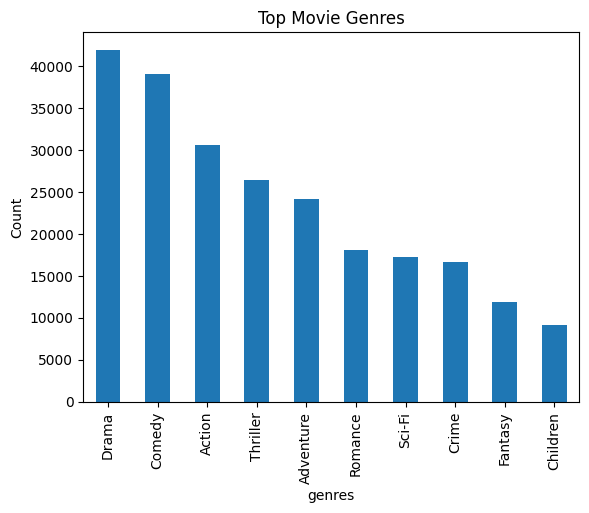

In [22]:
#Visualize genres
import matplotlib.pyplot as plt
movies_genres = movies['genres'].str.split('|').explode()
movies_genres.value_counts().head(10).plot(kind='bar')
plt.title("Top Movie Genres")
plt.xlabel("genres")
plt.ylabel("Count")
plt.show()

### 2.4.2 Most Rated Movies

In [66]:
most_rated = ratings.groupby('movieId')['rating'].count().reset_index()
most_rated.columns = ['movieId', 'rating_count']
most_rated = most_rated.merge(movies[['movieId', 'title']], on='movieId')
most_rated = most_rated.sort_values('rating_count', ascending=False).head(10).reset_index(drop=True)

print(most_rated[['title', 'rating_count']])





                                       title  rating_count
0                        Forrest Gump (1994)           329
1           Shawshank Redemption, The (1994)           317
2                        Pulp Fiction (1994)           307
3           Silence of the Lambs, The (1991)           279
4                         Matrix, The (1999)           278
5  Star Wars: Episode IV - A New Hope (1977)           251
6                       Jurassic Park (1993)           238
7                          Braveheart (1995)           237
8          Terminator 2: Judgment Day (1991)           224
9                    Schindler's List (1993)           220


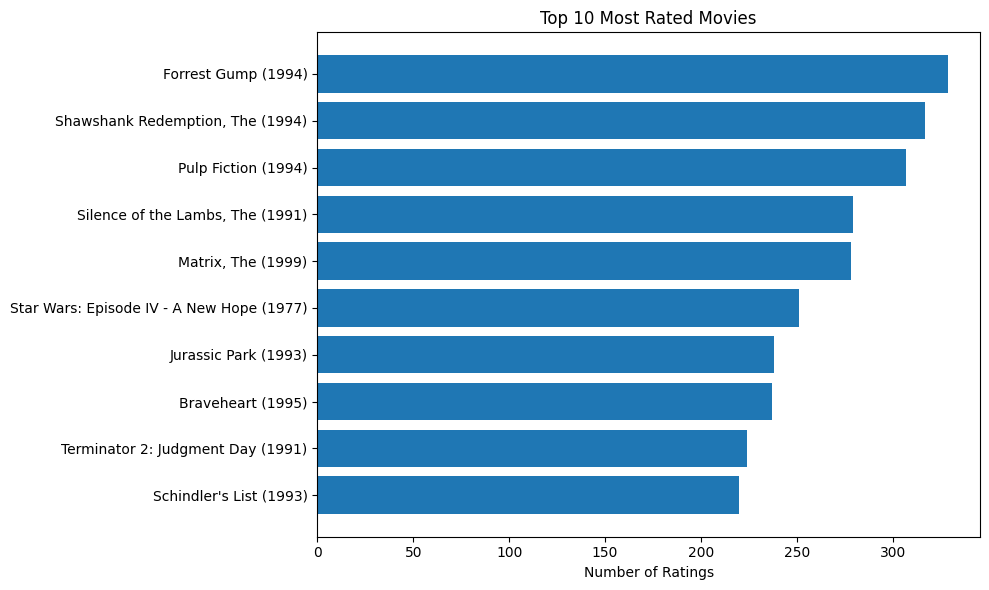

In [67]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(most_rated['title'][::-1], most_rated['rating_count'][::-1])
plt.xlabel('Number of Ratings')
plt.title('Top 10 Most Rated Movies')
plt.tight_layout()
plt.show()



In [25]:
#Most frequent movies
movies['title'].value_counts().head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: count, dtype: int64

In [26]:
#Top 10 most recommended movie
movies.groupby('title') \
      .count() \
      .sort_values(by='movieId', ascending=False) \
      .head(10)

,movieId,genres,userId,rating,timestamp
title,,,,,
Forrest Gump (1994),329,329,329,329,329
"Shawshank Redemption, The (1994)",317,317,317,317,317
Pulp Fiction (1994),307,307,307,307,307
"Silence of the Lambs, The (1991)",279,279,279,279,279
"Matrix, The (1999)",278,278,278,278,278
Star Wars: Episode IV - A New Hope (1977),251,251,251,251,251
Jurassic Park (1993),238,238,238,238,238
Braveheart (1995),237,237,237,237,237
Terminator 2: Judgment Day (1991),224,224,224,224,224


In [27]:
#Create content features
movies['content'] = (movies['title'].astype(str) + '' + 
movies['genres'].astype(str))

### 2.4.3 Rating Distribution

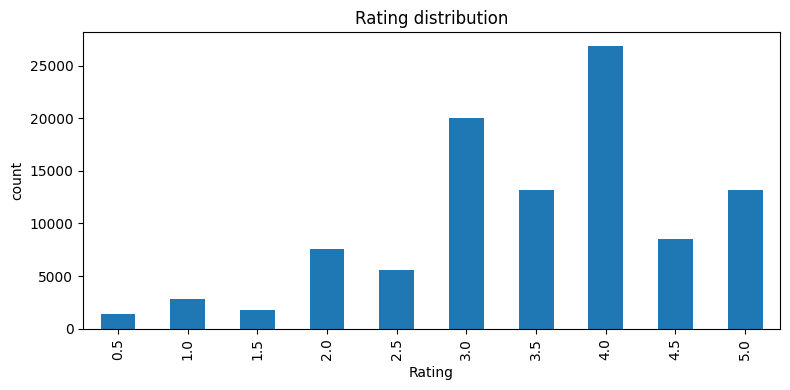

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [28]:


ratings['rating'].value_counts().sort_index().plot(kind='bar', figsize=(8, 4))
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('count')
plt.tight_layout()
plt.show()

print(ratings['rating'].describe())

## 3. DATA PREPARATION

Data preparation involved transforming the raw MovieLens dataset into a structured format suitable for building a recommendation system. This phase ensured that the data was clean, intergrated and formatted for both collaborative filtering and content-based filtering. 

# 3.1 Merge the dataset

In [29]:
#Merge ratings and Movies
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

data = pd.merge(ratings, movies, on='movieId')

In [30]:
tag_agg = tags.groupby('movieId')['tag'].apply(lambda x: ''.join(x)).reset_index()

In [31]:
ratings_movies = ratings.merge(movies, on='movieId', how='left')
print("ratings_movies shape:", ratings_movies.shape)

ratings_movies shape: (100836, 6)


In [32]:
full_df = ratings_movies.merge(tag_agg, on='movieId', how='left')

# 3.2 Check for missing values and duplicates

In [33]:
data = pd.merge(ratings, movies, on='movieId')

In [34]:
#check for missing values
data.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [35]:
data.drop_duplicates(inplace=True)

# 3.3 Build content features

In [36]:
import pandas as pd
movies = pd.read_csv('movies.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words='english')
movies['genres'] = movies['genres'].fillna('')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [38]:
#Genres cleaned for TF-IDF

movies_unique = movies[['movieId', 'title', 'genres']].drop_duplicates(subset='movieId').reset_index(drop=True)
movies_unique['genres_clean'] = movies_unique['genres'].str.replace('|', ' ', regex=False)
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies_unique['genres_clean'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(movies_unique.index, index=movies_unique['title']).drop_duplicates()

## 3.4 Build Collaborative Filtering Dataframe

In [39]:
cf_df = ratings[['userId', 'movieId', 'rating']]
print("cf_df shape:", cf_df.shape)
print(cf_df.head())

cf_df shape: (100836, 3)
   userId  movieId  rating
0       1        1     4.0
1       1        3     4.0
2       1        6     4.0
3       1       47     5.0
4       1       50     5.0


#  4 MODELLING

Under the modelling phase, we build three models that together form a hybrid recommendation system. That is, content-based filtering using TF-IDF vectorization to convert movie genres into numerical vectors and computes cosine similarity between movies. This allows us to find movies that are similar in terms of genre.

A collaborative filtering model is built next using Singular Value Decomposition(SVD) from the surprise library. SVD learns latent features from user rating history to predict how a user would rate an unseen movie.
First, we train a baseline SVD model, then use GridSearchCV to tune the hyperparameters and improve performance.

Finally, we combine both approaches into a hybrid recommendation model to overcome the key weaknesses of both individual models.

## 4.1 Content-based Filtering

Content-based filtering recommends movies similar to a given title based on movie attributes.In this project, we use movie genre as the content feature

In [40]:
#Creating a recommendation function
def recommend(title, cosine_sim=cosine_sim):
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]  

    movies_indices = [i[0] for i in sim_scores] 

    return movies['title'].iloc[movies_indices]

In [41]:
recommend("Toy Story (1995)")

1706                                          Antz (1998)
2355                                   Toy Story 2 (1999)
2809       Adventures of Rocky and Bullwinkle, The (2000)
3000                     Emperor's New Groove, The (2000)
3568                                Monsters, Inc. (2001)
6194                                     Wild, The (2006)
6486                               Shrek the Third (2007)
6948                       Tale of Despereaux, The (2008)
7760    Asterix and the Vikings (Astérix et les Viking...
8219                                         Turbo (2013)
Name: title, dtype: str

The recommendation function returns a list of movies that are most similar to the input movie. the similarity is computed using cosine similarity on TF-IDF transformed movie metadata. The higer the similarity score, the more related the movies are in terms of genre and content features.

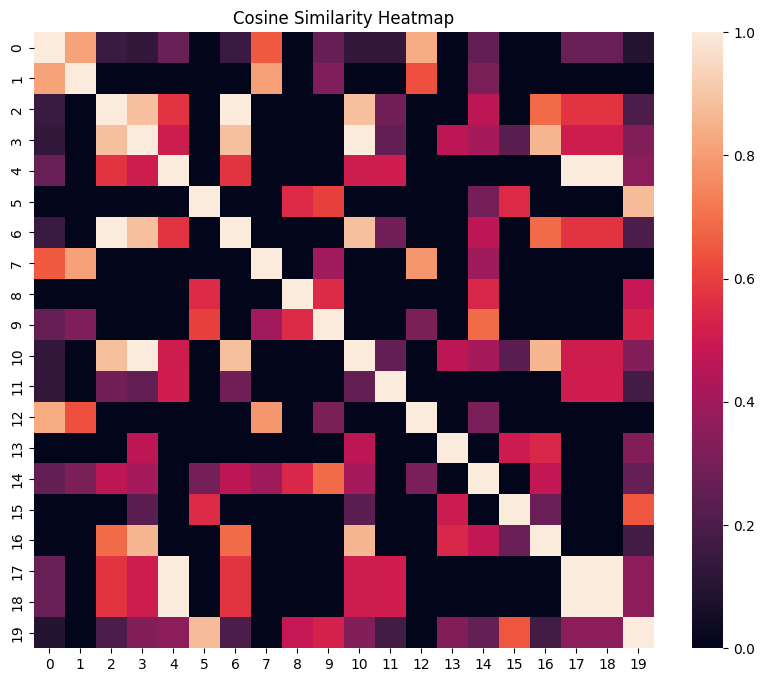

In [42]:
# Cosine Similarity Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

sample = cosine_sim[:20, :20]

plt.figure(figsize=(10,8))
sns.heatmap(sample)
plt.title('Cosine Similarity Heatmap')
plt.show()

In [43]:
# Top N similar movies

def similar_movies(title, n=10):
  idx = indices[title]
  sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:n+1]


  titles = [movies_unique['title'].iloc[i[0]]for i in sim_scores]
  scores = [i[1] for i in sim_scores]

  plt.figure(figsize=(9,5))
  plt.barh(title[::-1], scores[::-1])
  plt.xlabel('cosine similarity score')
  plt.title(f'Top {n} movies similar to "{title}"')
  plt.tight_layout()
  plt.show()


  

In [44]:
# check indices exists and title is in it
title = "Toy Story (1995)"
print(title in indices)


True


In [45]:
# see all titles that contain Toy story
print(movies_unique[movies_unique['title'].str.contains('Toy Story')])

      movieId               title  \
0           1    Toy Story (1995)   
2355     3114  Toy Story 2 (1999)   
7355    78499  Toy Story 3 (2010)   

                                                genres  \
0          Adventure|Animation|Children|Comedy|Fantasy   
2355       Adventure|Animation|Children|Comedy|Fantasy   
7355  Adventure|Animation|Children|Comedy|Fantasy|IMAX   

                                          genres_clean  
0          Adventure Animation Children Comedy Fantasy  
2355       Adventure Animation Children Comedy Fantasy  
7355  Adventure Animation Children Comedy Fantasy IMAX  


In [46]:
# check sim_scores is populated
idx = indices[title]
sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:11]
print(sim_scores)

[(1706, np.float64(1.0)), (2355, np.float64(1.0)), (2809, np.float64(1.0)), (3000, np.float64(1.0)), (3568, np.float64(1.0)), (6194, np.float64(1.0)), (6486, np.float64(1.0)), (6948, np.float64(1.0)), (7760, np.float64(1.0)), (8219, np.float64(1.0))]


In [47]:
# check titles and scores are extracted correctly
title =[movies_unique['title'].iloc[i[0]] for i in sim_scores]
scores = [i[1] for i in sim_scores]
print(title)
print(scores)

['Antz (1998)', 'Toy Story 2 (1999)', 'Adventures of Rocky and Bullwinkle, The (2000)', "Emperor's New Groove, The (2000)", 'Monsters, Inc. (2001)', 'Wild, The (2006)', 'Shrek the Third (2007)', 'Tale of Despereaux, The (2008)', 'Asterix and the Vikings (Astérix et les Vikings) (2006)', 'Turbo (2013)']
[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


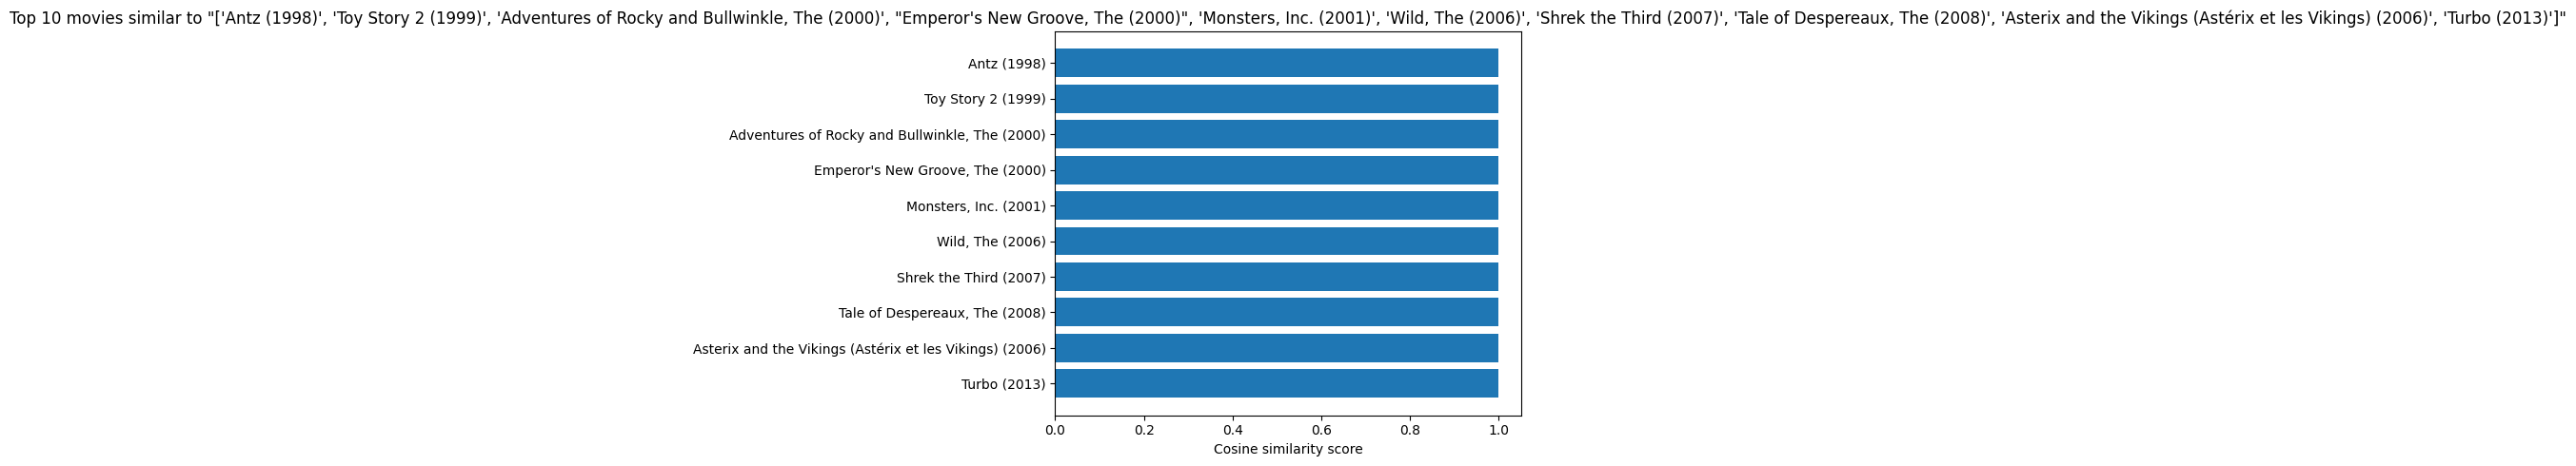

In [48]:
# plot 10 movies
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.barh(title[::-1], scores[::-1])
plt.xlabel('Cosine similarity score')
plt.title(f'Top 10 movies similar to "{title}"')
plt.tight_layout()
plt.show()


## 4.2 Collaborative Filtering

The underlying assumption is that users who have shown similar preferences in the past are likely to have similar tastes in the future. For example, if two users have rated several movies similarly, movies liked by one user can be recommended to the other. In this project, i will use collaborative filtering to analyze user movie ratings from the MovieLens dataset and predict movies that a user may enjoy based on ratings patterns from similar users and movies. This approach enables the creation of personalized movie recommendations without requiring detailed information about movie content.

In [49]:
print("ratings_movies shape:", ratings_movies.shape)
print("columns:", ratings_movies.columns.tolist())

ratings_movies shape: (100836, 6)
columns: ['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres']


In [50]:
cf_df = ratings_movies[['userId', 'movieId', 'rating']]

In [51]:
#Convert data for surprise
from surprise import Reader, Dataset
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(cf_df, reader)

In [52]:
#Train-test split
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

### 4.2.1 Baseline SVD

In [53]:
#Train the SVD model
from surprise import SVD
svd_model = SVD()
svd_model.fit(trainset)

In [54]:
#Make predictions

predictions = svd_model.test(testset)

In [55]:
#Evaluate performance(RMSE) 

from surprise import accuracy
accuracy.rmse(predictions)

RMSE: 0.8822


np.float64(0.8821721141934468)

In [56]:

#Train baseline model

svd_model = SVD()
svd_model.fit(trainset)


In [57]:
#Evaluate the model
predictions = svd_model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8841


np.float64(0.8841176612930786)

## 4.3 Hyperparameter Tuning using GridSearchCV



In [58]:
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.05, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
gs.fit(data)

print("Best RMSE:", gs.best_score['rmse'])
print("Best params:", gs.best_params['rmse'])

Best RMSE: 0.8624035359275487
Best params: {'n_factors': 150, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


## 4.4 Final Model using Best Params

In [59]:
best_params = gs.best_params['rmse']
final_model = SVD(
    n_factors=best_params['n_factors'],
    n_epochs=best_params['n_epochs'],
    lr_all=best_params['lr_all'],
    reg_all=best_params['reg_all']
)
final_model.fit(trainset)

predictions = final_model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8602


np.float64(0.8602072713792454)

Hyperparameter tuning was performed using GridSearchCv from the surprise library to optimize the SVD model.
Parameters such as number of latent factors, learning rate, number of epochs and regularization strength were tuned using cross-validation.
The optimized model showed improved predictive performance measured using RMSE. The RMSE score changed from 0.88 to 0.86.

##  4.5 Hybrid Recommendation Function

The objective of this section is to combine content-based filtering and collaborative filtering techniques to generate more personalized movie recommendation. The hybrid model uses movie metadata to identify similar movies while also incorporating user rating patterns learned through matrix factorization(SVD).

In [60]:
def hybrid_recommendations(user_id, title, cosine_sim=cosine_sim):
  # Get index of the movie
  idx = indices[title]

  
  # Get similarity scores

  sim_scores = list(enumerate(cosine_sim[idx]))

  # Sort movies by similarity
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

  # Top 20 similar movies (excluding itself)
  sim_scores = sim_scores[1:21]

  movie_indices = [i[0] for i in sim_scores]

  # Get candidate movies
  candidates = movies.iloc[movie_indices][['movieId', 'title',]].copy()

  # Predict ratings for user
  candidates['estimated_rating'] = candidates['movieId'].apply(lambda x: svd_model.predict(user_id, x).est)

  # Rank by predicted rating
  candidates = candidates.sort_values('estimated_rating', ascending=False)
  return candidates.head(10)

In [61]:
# Testing the Hybrid Model
hybrid_recommendations(user_id=1, title="Toy Story (1995)")

,movieId,title,estimated_rating
3568,4886,"Monsters, Inc. (2001)",4.836921
9430,166461,Moana (2016),4.759328
3000,4016,"Emperor's New Groove, The (2000)",4.617505
8900,134853,Inside Out (2015),4.575373
2355,3114,Toy Story 2 (1999),4.502277
1505,2033,"Black Cauldron, The (1985)",4.408222
4424,6536,Sinbad: Legend of the Seven Seas (2003),4.329121
8219,103755,Turbo (2013),4.228029
1706,2294,Antz (1998),4.209446
7760,91355,Asterix and the Vikings (Astérix et les Viking...,4.196112


In [62]:
# Removing duplicates
movies_unique = movies_unique.drop_duplicates(subset='movieId').reset_index(drop=True)
indices = pd.Series(movies_unique.index, index=movies_unique['title']).drop_duplicates()
print(movies_unique.shape)

(9742, 4)


In [63]:
hybrid_recommendations(user_id=1, title="Toy Story (1995)")

,movieId,title,estimated_rating
3568,4886,"Monsters, Inc. (2001)",4.836921
9430,166461,Moana (2016),4.759328
3000,4016,"Emperor's New Groove, The (2000)",4.617505
8900,134853,Inside Out (2015),4.575373
2355,3114,Toy Story 2 (1999),4.502277
1505,2033,"Black Cauldron, The (1985)",4.408222
4424,6536,Sinbad: Legend of the Seven Seas (2003),4.329121
8219,103755,Turbo (2013),4.228029
1706,2294,Antz (1998),4.209446
7760,91355,Asterix and the Vikings (Astérix et les Viking...,4.196112


In [64]:
# Content-based filtering score
def avg_similarity_score(title, n=10):
    idx = indices[title]
    sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:n+1]
    scores = [i[1] for i in sim_scores]
    return np.mean(scores)
    
test_titles = ["Toy Story (1995)", "Pulp Fiction (1994)", "Matrix, The (1999)"]
cb_scores = [avg_similarity_score(t) for t in test_titles]
cb_avg = np.mean(cb_scores)

In [65]:
# Collaborative filtering scores
svd_baseline = SVD()
svd_baseline.fit(trainset)
baseline_rmse = accuracy.rmse(svd_baseline.test(testset), verbose=False)
tuned_rmse = accuracy.rmse(final_model.test(testset), verbose=False)